# Univariate Analysis

Objective:
- Understand distributions of individual variables
- Identify skewness, imbalance, rare categories
- Flag features that may need transformation or exclusion

Input: data/interim/cleaned_data.csv


In [1]:
# Loading Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [2]:
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
data_path = os.path.join(project_root,'data', 'interim', 'cleaned_data.csv')

crime_data = pd.read_csv(data_path)
crime_data.shape

(10000, 10)

In [3]:
numeric_cols = crime_data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = crime_data.select_dtypes(include=['object']).columns.tolist()

numeric_cols, categorical_cols

(['crime_id',
  'latitude',
  'longitude',
  'hour',
  'victim_age',
  'suspect_age',
  'arrest_made'],
 ['crime_type', 'day_of_week', 'weapon_used'])

In [7]:
crime_data[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
crime_id,10000.0,5000.500000,2886.895680,1.000000,2500.750000,5000.500000,7500.250000,10000.00000
latitude,10000.0,0.165749,51.804459,-89.978644,-43.834204,0.401041,44.278058,89.98068
longitude,10000.0,-0.507375,104.082412,-179.996653,-90.816040,-1.784043,89.719896,179.93598
hour,10000.0,11.605400,6.900381,0.000000,6.000000,12.000000,18.000000,23.00000
victim_age,10000.0,44.340200,20.264218,10.000000,27.000000,45.000000,62.000000,79.00000
suspect_age,10000.0,42.182800,15.792901,15.000000,29.000000,42.000000,56.000000,69.00000
arrest_made,10000.0,0.300400,0.458455,0.000000,0.000000,0.000000,1.000000,1.00000


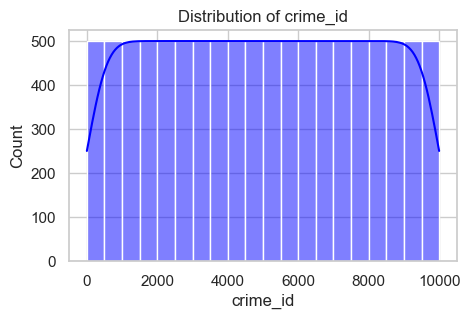

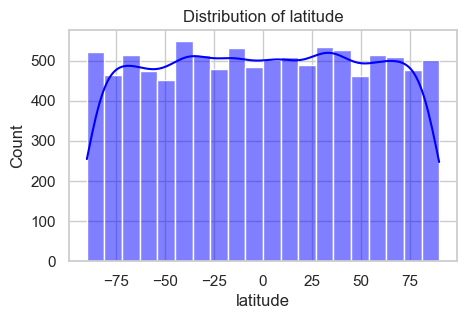

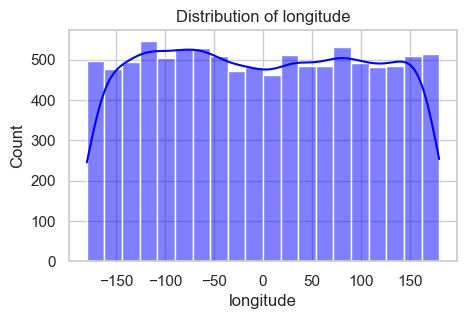

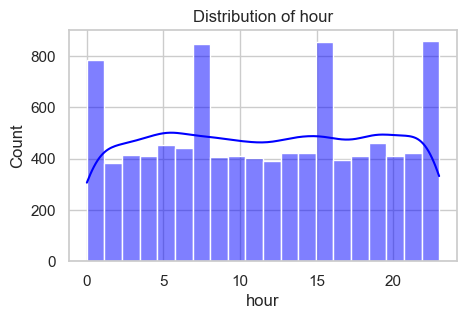

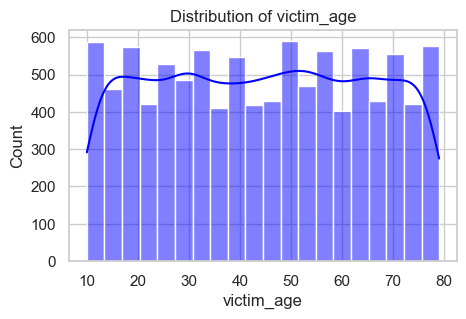

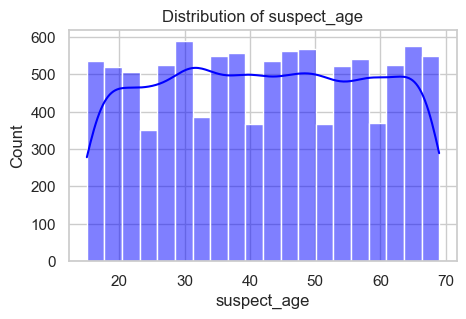

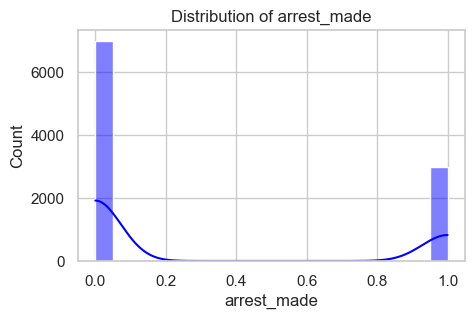

In [10]:
for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(crime_data[col], bins=20, kde=True, color='blue')
    plt.title(f'Distribution of {col}')

    plt.show()

In [18]:
for col in numeric_cols:
    q1 = crime_data[col].quantile(0.25)
    q3 = crime_data[col].quantile(0.75)
    iqr = q3 - q1
    outlier_count = ((crime_data[col] < (q1 - 1.5 * iqr)) | (crime_data[col] > (q3 + 1.5 * iqr))).mean()
    print(f"{col}: outlier rate = {outlier_count:.2%}")

crime_id: outlier rate = 0.00%
latitude: outlier rate = 0.00%
longitude: outlier rate = 0.00%
hour: outlier rate = 0.00%
victim_age: outlier rate = 0.00%
suspect_age: outlier rate = 0.00%
arrest_made: outlier rate = 0.00%


In [19]:
for col in categorical_cols:
    display(crime_data[col].value_counts().head())

crime_type
Fraud        1464
Burglary     1439
Homicide     1429
Assault      1428
Vandalism    1426
Name: count, dtype: int64

day_of_week
Tue    1522
Thu    1470
Sun    1431
Fri    1413
Sat    1412
Name: count, dtype: int64

weapon_used
blunt object    2552
knife           2533
unknown         2475
gun             2440
Name: count, dtype: int64

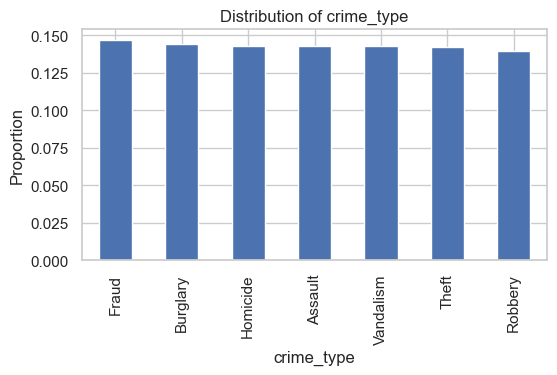

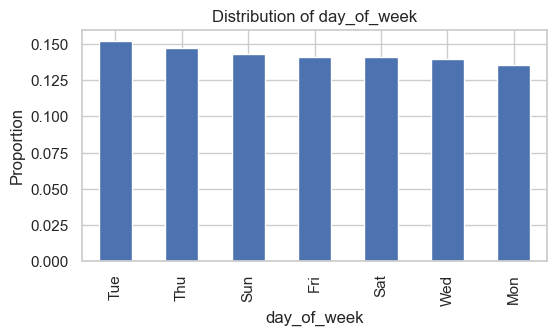

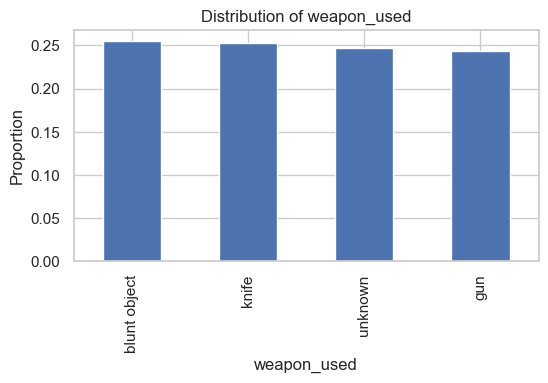

In [21]:
for col in categorical_cols:
    plt.figure(figsize=(6,3))

    crime_data[col].value_counts(normalize=True).plot(kind='bar')
    plt.title(f"Distribution of {col}")
    plt.ylabel('Proportion')
    plt.show()

In [22]:
crime_data["weapon_used"].value_counts(normalize=True)

weapon_used
blunt object    0.2552
knife           0.2533
unknown         0.2475
gun             0.2440
Name: proportion, dtype: float64

## Feature-Level Observations

- Numeric features show moderate right skew
- Several categorical features are imbalanced
- `weapon_used = "unknown"` is frequent but meaningful
- No single feature appears invalid or unusable at this stage


## Decisions from Univariate Analysis

- No features dropped at this stage
- No transformations applied yet
- Skewness and imbalance noted for feature engineering
